# 리뷰 벡터화 파이프라인

이 노트북은 다음을 수행합니다.

- Excel 파일(`keyword_reviews00.xlsx`, `keyword_reviews01.xlsx`) 로드 및 소스 구분 라벨링
- 텍스트 자동 컬럼 감지 및 정제
- TF‑IDF(char 3~5gram) 벡터화 생성 및 저장
- 소스별 상위 TF‑IDF 용어 리포트 엑셀로 내보내기
- 선택: 문장 임베딩(Sentence Transformers, 한국어 우선) 생성 및 저장(오프라인이면 건너뜀)

출력 파일은 `03.CX_Group4/vectorization/outputs/`에 저장됩니다.

In [1]:
# 환경 설정 및 라이브러리 불러오기
from __future__ import annotations
import os
import re
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

# 경로 설정
BASE = Path(r"c:/Users/lgdx/LG_DX_School/03.CX_Group4/vectorization")
IN_DIR = BASE
OUT_DIR = BASE / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILE0 = IN_DIR / "keyword_reviews00.xlsx"
FILE1 = IN_DIR / "keyword_reviews01.xlsx"

print("입력 파일 존재 여부:")
print(FILE0, FILE0.exists())
print(FILE1, FILE1.exists())

입력 파일 존재 여부:
c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\keyword_reviews00.xlsx True
c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\keyword_reviews01.xlsx True


In [2]:
# 데이터 로더: 텍스트 컬럼 자동 감지 및 정제

TEXT_CANDIDATE_COLS = [
    "text", "review", "reviews", "content", "contents", "comment", "comments",
    "리뷰", "본문", "내용", "댓글", "코멘트", "텍스트"
]

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MULTI_SPACE = re.compile(r"\s+")


def detect_text_col(df: pd.DataFrame) -> str | None:
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in TEXT_CANDIDATE_COLS:
        if cand in cols_lower:
            return cols_lower[cand]
    # fallback: object dtype with longest avg length
    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    if not obj_cols:
        return None
    avg_lens = [(c, df[c].astype(str).str.len().mean()) for c in obj_cols]
    avg_lens.sort(key=lambda x: x[1], reverse=True)
    return avg_lens[0][0]


def clean_text(s: str) -> str:
    if not isinstance(s, str):
        s = "" if pd.isna(s) else str(s)
    s = s.replace("\u200b", " ")
    s = URL_RE.sub(" ", s)
    s = re.sub(r"[\r\n\t]", " ", s)
    s = MULTI_SPACE.sub(" ", s)
    s = s.strip()
    return s


def load_and_prepare(paths: list[Path]) -> pd.DataFrame:
    frames = []
    for i, p in enumerate(paths):
        if not p.exists():
            print(f"경고: 파일 없음 -> {p}")
            continue
        df = pd.read_excel(p)
        if df.empty:
            print(f"경고: 빈 엑셀 -> {p}")
            continue
        text_col = detect_text_col(df)
        if not text_col:
            print(f"경고: 텍스트 컬럼을 찾지 못함 -> {p}, 사용 가능한 컬럼: {list(df.columns)}")
            continue
        tmp = df[[text_col]].copy()
        tmp.rename(columns={text_col: "text"}, inplace=True)
        tmp["text"] = tmp["text"].map(clean_text)
        tmp["source"] = p.name
        tmp = tmp[tmp["text"].str.len() > 0]
        frames.append(tmp)
    if not frames:
        return pd.DataFrame(columns=["text", "source"])    
    return pd.concat(frames, ignore_index=True)


raw = load_and_prepare([FILE0, FILE1])
print(raw.head())
print(raw["source"].value_counts(dropna=False))

                                                text                  source
0  2025 LG Gram Pro를 얻는 것을 고려하고 있으며 255H 모델이 내 랩에...  keyword_reviews00.xlsx
1  LG Gram Pro 2-in-1 16 인치, 얇고 경량 노트북, Windows 1...  keyword_reviews00.xlsx
2  LG Gram Pro 노트북이 새로운 RTX 50 시리즈 그래픽 칩과 함께 출시 될...  keyword_reviews00.xlsx
3  LG GRAM PRO 17 "2025- 모욕 열 페이스트 응용 프로그램을 넘어서, ...  keyword_reviews00.xlsx
4  LG GRAM PRO 17 2025 (17Z90TP Core Ultra 7 255H...  keyword_reviews00.xlsx
source
keyword_reviews01.xlsx    277
keyword_reviews00.xlsx    261
Name: count, dtype: int64


In [5]:
# 불용어 및 토큰 필터 정의
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

KO_STOPWORDS = {
    # 조사/어미/불용어(대표)
    "하다","되다","이다","있다","없다","같다","되","및","그리고","그러나","하지만","또한","등","더",
    "정말","그냥","매우","너무","진짜","제","저","내","우리","여기","저기","그","이","저","것","수","때","또",
    "에서","으로","에게","까지","부터","만","도","은","는","이","가","을","를","과","와","로","만큼","보다",
    "합니다","합니다.","했다","한다","한","하는","하며","하며","했다.","있습니다","있어요","입니다","입니다.","네요",
}

ENDINGS = ("니다","니다.","습니다","습니다.","다.","요.","요 ","해요","했어요","했습니다","했다","하고","하며","하는 ","으로 ")
PUNCT_ALL = set(string.punctuation)


def is_noise_chargram(t: str) -> bool:
    s = t.strip()
    if len(s) < 3:
        return True
    # 공백 포함 n-gram 제거 (문장부호/띄어쓰기 위주 토큰 억제)
    if any(ch.isspace() for ch in s):
        return True
    # 전부 비문자(문장부호 등)
    if all(not ch.isalnum() and not ('\uAC00' <= ch <= '\uD7A3') for ch in s):
        return True
    # 숫자 비율 높으면 제거
    num_ratio = sum(ch.isdigit() for ch in s) / len(s)
    if num_ratio > 0.5:
        return True
    # 공손체/서술 어미 패턴
    if any(s.endswith(e) for e in ENDINGS):
        return True
    # 반복되는 점, 따옴표 등
    if s.count('.') >= 2 or s.count('"') >= 2 or s.count("'") >= 2:
        return True
    return False

# 한국어 토크나이저 기반 전처리(Word TF-IDF 용)
# 자바/리소스 부재시 안전하게 패스
try:
    from konlpy.tag import Okt
    okt = Okt()

    def ko_tokenize(text: str):
        if not isinstance(text, str):
            text = "" if pd.isna(text) else str(text)
        text = clean_text(text)
        toks = []
        for token, pos in okt.pos(text, norm=True, stem=True):
            if pos in {"Noun","Adjective","Verb"}:
                token = token.lower()
                if token.isdigit():
                    continue
                if len(token) < 2:
                    continue
                if token in KO_STOPWORDS:
                    continue
                if token in ENGLISH_STOP_WORDS:
                    continue
                toks.append(token)
        return toks
except Exception as e:
    print("Okt 초기화 실패(Word TF-IDF는 건너뜀 가능):", e)
    okt = None
    def ko_tokenize(text: str):
        # 폴백: 공백 토큰화
        if not isinstance(text, str):
            text = "" if pd.isna(text) else str(text)
        text = clean_text(text)
        return [w for w in re.split(r"\s+", text) if len(w) >= 2]

Okt 초기화 실패(Word TF-IDF는 건너뜀 가능): No JVM shared library file (jvm.dll) found. Try setting up the JAVA_HOME environment variable properly.


In [8]:
# TF-IDF 벡터화 (Char 3~5gram, 한국어/띄어쓰기에 강건)

if raw.empty:
    raise SystemExit("입력 데이터가 없습니다. 엑셀 파일과 텍스트 컬럼을 확인하세요.")

vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.9,
    strip_accents=None,
    lowercase=False,
)

X = vectorizer.fit_transform(raw["text"].tolist())
feature_names = np.array(vectorizer.get_feature_names_out())

print("TF-IDF shape:", X.shape)

# 전체 상위 n-gram 미리보기 (노이즈 필터 적용)
means = np.asarray(X.mean(axis=0)).ravel()
order = means.argsort()[::-1]
preview = []
for idx in order:
    term = feature_names[idx]
    if is_noise_chargram(term):
        continue
    preview.append(term)
    if len(preview) >= 20:
        break
print("상위 토큰 예시(클린):", preview)

# 소스별 상위 용어 집계 및 저장 (노이즈 필터 적용)
reports = []
for source, idx in raw.groupby("source").indices.items():
    sub = X[idx]
    sub_means = np.asarray(sub.mean(axis=0)).ravel()
    ord_idx = sub_means.argsort()[::-1]
    top_terms = []
    top_scores = []
    for j in ord_idx:
        term = feature_names[j]
        if is_noise_chargram(term):
            continue
        top_terms.append(term)
        top_scores.append(sub_means[j])
        if len(top_terms) >= 50:
            break
    df_rep = pd.DataFrame({
        "source": source,
        "term": top_terms,
        "tfidf_mean": top_scores,
    })
    reports.append(df_rep)

report_df = pd.concat(reports, ignore_index=True)
report_path = OUT_DIR / "tfidf_top_terms_by_source.xlsx"
report_df.to_excel(report_path, index=False)
print("리포트 저장:", report_path)

# 희소 행렬과 메타 저장 (npz + csv)
from scipy import sparse

sparse_path = OUT_DIR / "tfidf_matrix.npz"
meta_path = OUT_DIR / "tfidf_meta.csv"

sparse.save_npz(sparse_path, X)
raw[["source", "text"]].to_csv(meta_path, index=False)
print("행렬/메타 저장:", sparse_path, meta_path)

TF-IDF shape: (538, 174381)
상위 토큰 예시(클린): ['노트북', ' 노트북', 'Pro', ' Pro', ' 있습니', '있습니', ' Pro ', 'Pro ', '배터리', ' 배터리', '노트북 ', '니까?', '때문에', ' 때문에', '었습니', '배터리 ', 'ook', 'ram', '사용하', ' 사용하']
리포트 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\tfidf_top_terms_by_source.xlsx
행렬/메타 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\tfidf_matrix.npz c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\tfidf_meta.csv
행렬/메타 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\tfidf_matrix.npz c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\tfidf_meta.csv


In [9]:
# 선택: 문장 임베딩(Sentence Transformers)
# 네트워크/모델 다운로드가 차단된 환경이면 이 셀은 건너뛰어도 됩니다.
try:
    from sentence_transformers import SentenceTransformer
    import torch

    model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"임베딩 모델 로드: {model_name} on {device}")
    sbert = SentenceTransformer(model_name, device=device)
    embs = sbert.encode(raw["text"].tolist(), batch_size=64, show_progress_bar=True, convert_to_numpy=True)

    npz_path = OUT_DIR / "sbert_embeddings.npz"
    np.savez_compressed(npz_path, embeddings=embs)
    print("임베딩 저장:", npz_path)
except Exception as e:
    print("임베딩 생성을 건너뜀:", e)

임베딩 생성을 건너뜀: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.


In [10]:
# 보강: Word 단위 TF-IDF (한국어 형태소 기반)
# Okt 가용 시: Noun/Adj/Verb만 사용 + 불용어 제거

if okt is not None:
    word_vectorizer = TfidfVectorizer(
        tokenizer=ko_tokenize,
        token_pattern=None,  # 사용자 tokenizer 사용
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        lowercase=True,
    )
    Xw = word_vectorizer.fit_transform(raw["text"].tolist())
    vocab = np.array(word_vectorizer.get_feature_names_out())
    print("Word TF-IDF shape:", Xw.shape)

    # 전체 상위 토큰 미리보기
    w_means = np.asarray(Xw.mean(axis=0)).ravel()
    w_order = w_means.argsort()[::-1]
    print("Word 상위 토큰 예시:", vocab[w_order[:20]].tolist())

    # 소스별 리포트
    w_reports = []
    for source, idx in raw.groupby("source").indices.items():
        sub = Xw[idx]
        sub_means = np.asarray(sub.mean(axis=0)).ravel()
        ord_idx = sub_means.argsort()[::-1]
        top_k = 50
        w_top_terms = vocab[ord_idx[:top_k]]
        w_top_scores = sub_means[ord_idx[:top_k]]
        w_reports.append(pd.DataFrame({
            "source": source,
            "term": w_top_terms,
            "tfidf_mean": w_top_scores,
        }))
    w_report_df = pd.concat(w_reports, ignore_index=True)
    w_report_path = OUT_DIR / "word_tfidf_top_terms_by_source.xlsx"
    w_report_df.to_excel(w_report_path, index=False)
    print("Word 리포트 저장:", w_report_path)
else:
    print("Okt 미가용: Word TF-IDF 생략")

Okt 미가용: Word TF-IDF 생략


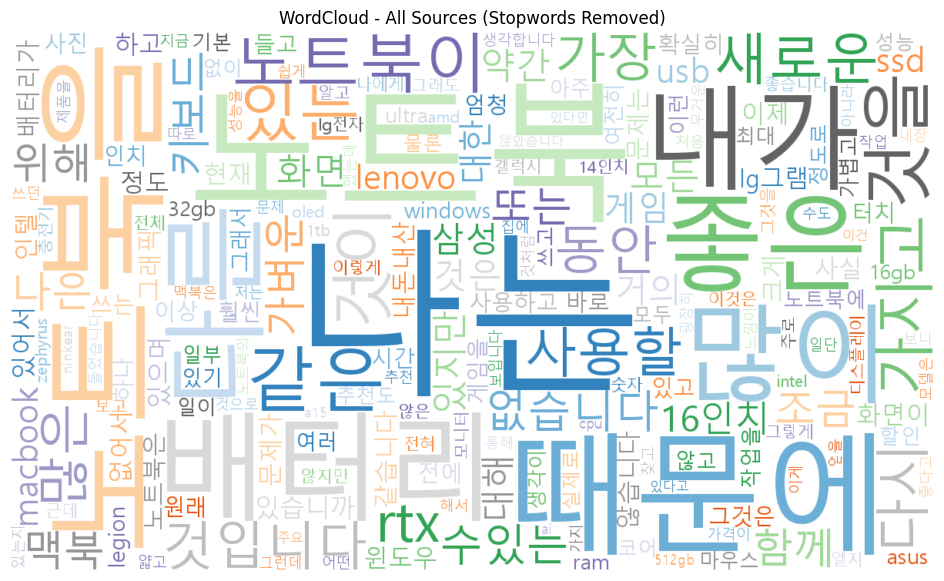

워드클라우드 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\wordcloud_all.png


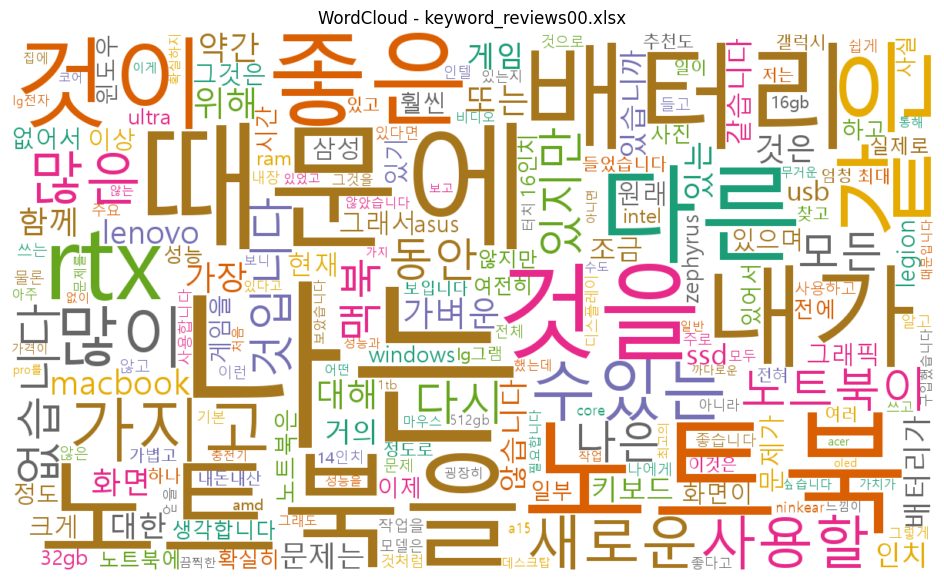

워드클라우드 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\wordcloud_keyword_reviews00.xlsx.png


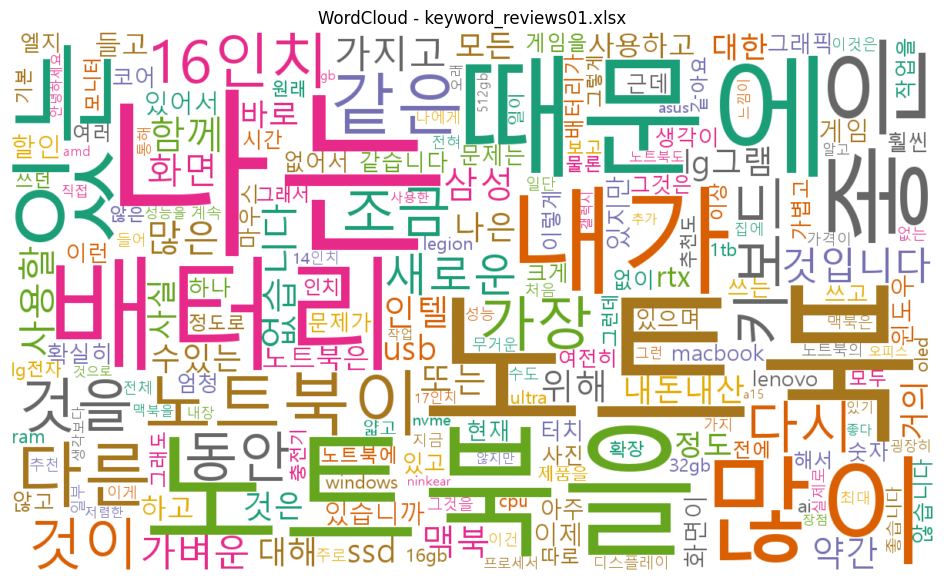

워드클라우드 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\wordcloud_keyword_reviews01.xlsx.png
상위 단어 표 저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\wordcloud_top_words_by_source.xlsx


In [ ]:
# 워드클라우드: 불용어 제외 토큰화 후 시각화
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 추가 도메인 불용어(필요시 확장)
EXTRA_STOP = {"lg", "gram", "pro", "그램", "프로", "제품", "사용", "구매", "리뷰"}
EXTRA_STOP = {w.lower() for w in EXTRA_STOP}

# 숫자/기호 제거 및 소문자 정규화
_token_word_re = re.compile(r"[\w]+", flags=re.UNICODE)

def tokenize_for_wc(text: str):
    if not isinstance(text, str):
        text = "" if pd.isna(text) else str(text)
    text = clean_text(text)
    # 우선 형태소(Okt) 사용, 안되면 단순 토큰화
    toks = []
    if okt is not None:
        try:
            for tok in ko_tokenize(text):  # ko_tokenize는 기본 불용어 일부 제거
                t = tok.lower()
                if t.isdigit():
                    continue
                if len(t) < 2:
                    continue
                if t in KO_STOPWORDS or t in ENGLISH_STOP_WORDS or t in EXTRA_STOP:
                    continue
                toks.append(t)
        except Exception:
            pass
    if not toks:
        # Fallback: 유니코드 단어 문자 기반
        for tok in _token_word_re.findall(text):
            t = tok.lower()
            if t.isdigit():
                continue
            if len(t) < 2:
                continue
            if t in KO_STOPWORDS or t in ENGLISH_STOP_WORDS or t in EXTRA_STOP:
                continue
            toks.append(t)
    return toks

# 전체 토큰 빈도
all_tokens = []
for s in raw["text"].tolist():
    all_tokens.extend(tokenize_for_wc(s))

if not all_tokens:
    print("토큰이 비어 있어 워드클라우드를 생성할 수 없습니다.")
else:
    freq_all = Counter(all_tokens)
    font_path = Path(r"C:/Windows/Fonts/malgun.ttf")
    font_arg = str(font_path) if font_path.exists() else None

    wc = WordCloud(
        width=1200, height=700,
        background_color="white",
        font_path=font_arg,
        colormap="tab20c"
    ).generate_from_frequencies(freq_all)

    plt.figure(figsize=(12,7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud - All Sources (Stopwords Removed)")
    out_png = OUT_DIR / "wordcloud_all.png"
    plt.savefig(out_png, bbox_inches="tight", dpi=150)
    plt.show()
    print("워드클라우드 저장:", out_png)

    # 소스별 워드클라우드 및 상위 단어 표
    rows = []
    for source, df_src in raw.groupby("source"):
        toks = []
        for s in df_src["text"].tolist():
            toks.extend(tokenize_for_wc(s))
        if not toks:
            print(f"{source}: 토큰 없음")
            continue
        freq = Counter(toks)
        wc_s = WordCloud(
            width=1200, height=700,
            background_color="white",
            font_path=font_arg,
            colormap="Dark2"
        ).generate_from_frequencies(freq)
        plt.figure(figsize=(12,7))
        plt.imshow(wc_s, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"WordCloud - {source}")
        safe_name = re.sub(r"[^\w.-]+","_", source)
        out_src = OUT_DIR / f"wordcloud_{safe_name}.png"
        plt.savefig(out_src, bbox_inches="tight", dpi=150)
        plt.show()
        print("워드클라우드 저장:", out_src)mm

        for term, cnt in freq.most_common(50):
            rows.append({"source": source, "term": term, "count": cnt})

    if rows:
        top_words_df = pd.DataFrame(rows)
        top_words_path = OUT_DIR / "wordcloud_top_words_by_source.xlsx"
        top_words_df.to_excel(top_words_path, index=False)
        print("상위 단어 표 저장:", top_words_path)

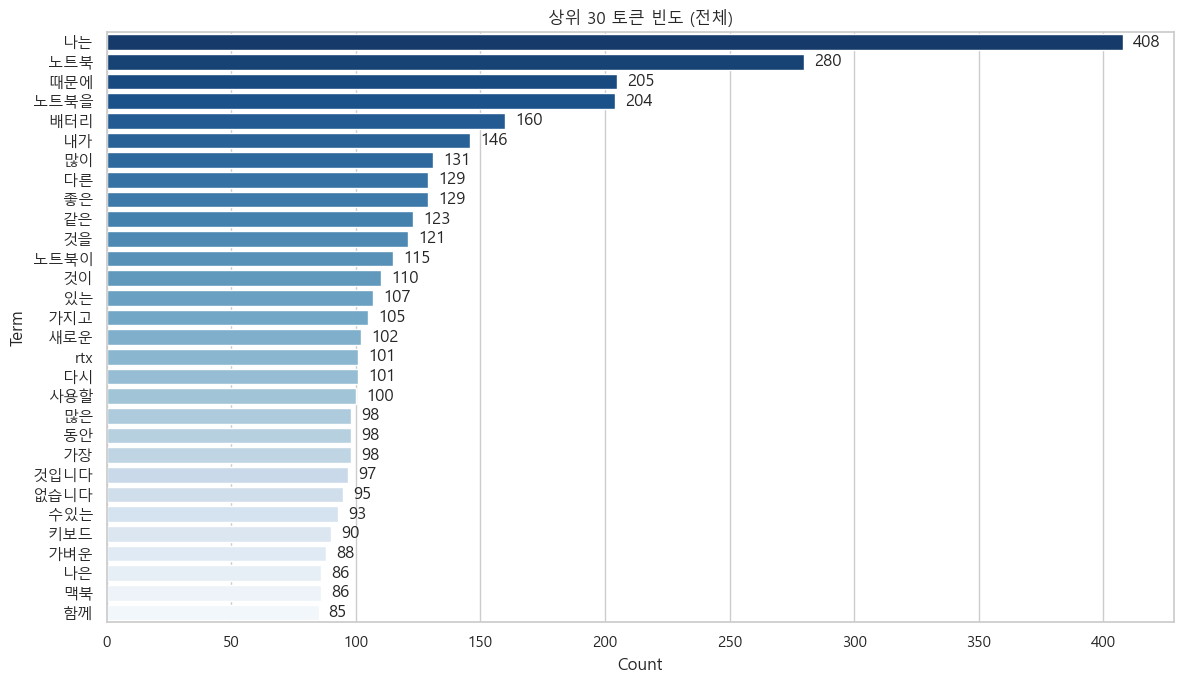

저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\freq_bar_all_top30.png
저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\freq_table_overall.csv


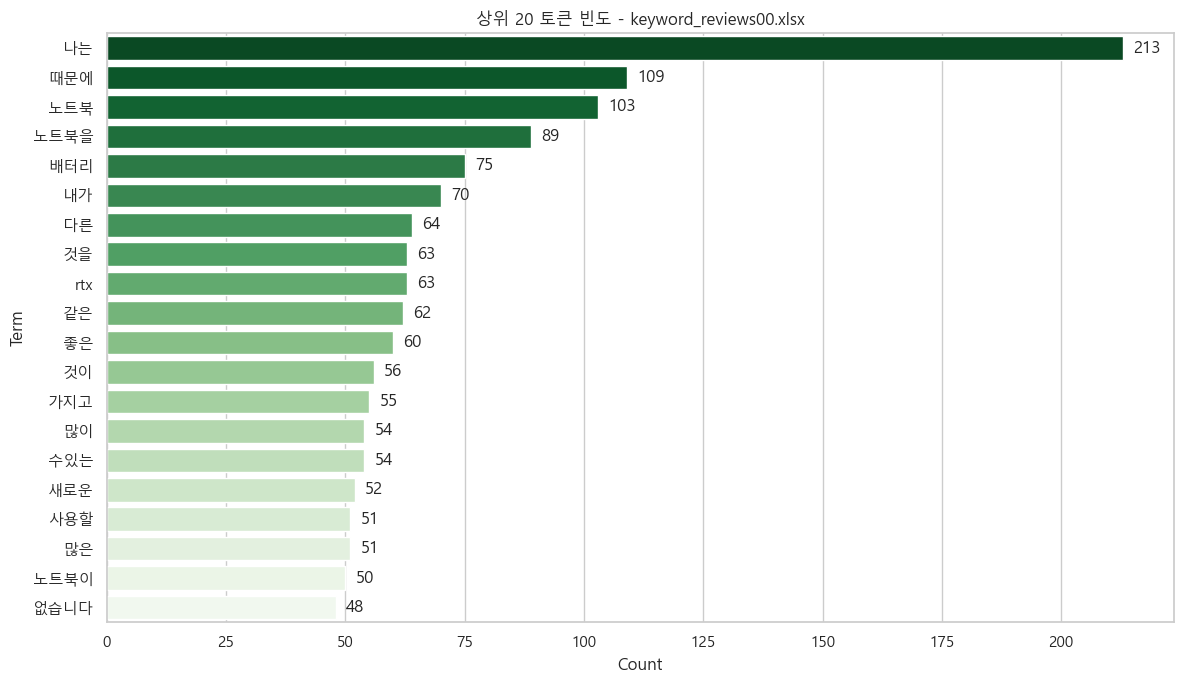

저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\freq_bar_keyword_reviews00.xlsx_top20.png


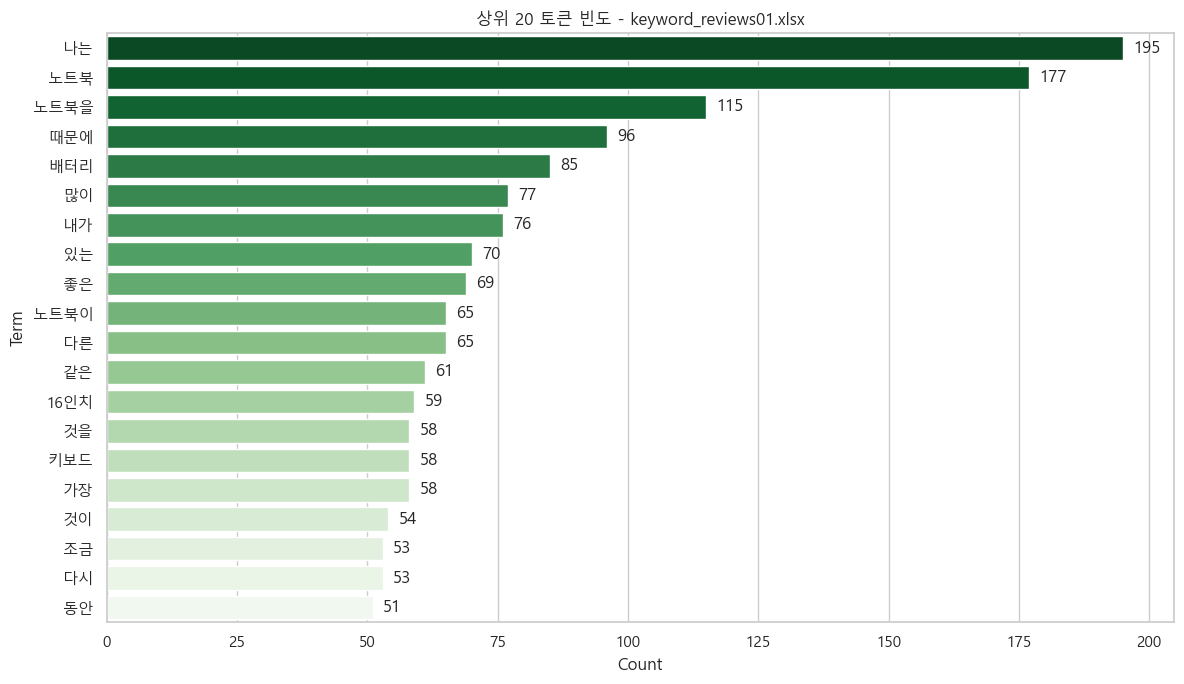

저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\freq_bar_keyword_reviews01.xlsx_top20.png
저장: c:\Users\lgdx\LG_DX_School\03.CX_Group4\vectorization\outputs\freq_table_by_source.xlsx


In [12]:
# 빈도수 시각화: 전체/소스별 토큰 상위 Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set(style="whitegrid")

# 한글 폰트 설정(가능 시)
try:
    plt.rcParams["font.family"] = "Malgun Gothic"
    plt.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

# 전체 빈도
all_tokens_vis = []
for s in raw["text"].tolist():
    all_tokens_vis.extend(tokenize_for_wc(s))

if not all_tokens_vis:
    print("토큰이 없어 빈도 시각화를 건너뜁니다.")
else:
    freq_all = Counter(all_tokens_vis)
    df_all = pd.DataFrame(freq_all.items(), columns=["term","count"]).sort_values("count", ascending=False)
    df_all["share"] = df_all["count"] / df_all["count"].sum()

    top_n = 30
    top_all = df_all.head(top_n)
    plt.figure(figsize=(12,7))
    ax = sns.barplot(data=top_all, x="count", y="term", palette="Blues_r")
    ax.set_title(f"상위 {top_n} 토큰 빈도 (전체)")
    ax.set_xlabel("Count")
    ax.set_ylabel("Term")
    for i, v in enumerate(top_all["count"].tolist()):
        ax.text(v + max(top_all["count"]) * 0.01, i, f"{v}", va="center")
    plt.tight_layout()
    out_all_bar = OUT_DIR / "freq_bar_all_top30.png"
    plt.savefig(out_all_bar, dpi=150)
    plt.show()
    print("저장:", out_all_bar)

    # 표 저장
    all_csv = OUT_DIR / "freq_table_overall.csv"
    df_all.to_csv(all_csv, index=False)
    print("저장:", all_csv)

    # 소스별 빈도 및 시각화
    by_rows = []
    for source, df_src in raw.groupby("source"):
        toks = []
        for s in df_src["text"].tolist():
            toks.extend(tokenize_for_wc(s))
        if not toks:
            print(f"{source}: 토큰 없음, 시각화 생략")
            continue
        freq_src = Counter(toks)
        df_src_freq = pd.DataFrame(freq_src.items(), columns=["term","count"]).sort_values("count", ascending=False)
        total_src = df_src_freq["count"].sum()
        df_src_freq["share"] = df_src_freq["count"] / total_src if total_src else 0
        df_src_freq["source"] = source
        by_rows.append(df_src_freq)

        top_k = 20
        top_src = df_src_freq.head(top_k)
        plt.figure(figsize=(12,7))
        ax = sns.barplot(data=top_src, x="count", y="term", palette="Greens_r")
        ax.set_title(f"상위 {top_k} 토큰 빈도 - {source}")
        ax.set_xlabel("Count")
        ax.set_ylabel("Term")
        for i, v in enumerate(top_src["count"].tolist()):
            ax.text(v + max(top_src["count"]) * 0.01, i, f"{v}", va="center")
        plt.tight_layout()
        safe = re.sub(r"[^\w.-]+","_", source)
        out_src_bar = OUT_DIR / f"freq_bar_{safe}_top{top_k}.png"
        plt.savefig(out_src_bar, dpi=150)
        plt.show()
        print("저장:", out_src_bar)

    if by_rows:
        freq_by_src = pd.concat(by_rows, ignore_index=True)
        by_src_path = OUT_DIR / "freq_table_by_source.xlsx"
        freq_by_src.to_excel(by_src_path, index=False)
        print("저장:", by_src_path)